In [2]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from pathlib import PureWindowsPath
import torchvision.models as models
from matplotlib.patches import Patch
from monai.transforms import LoadImage
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Resized
)

from monai.networks.nets import resnet18

import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")
from Radiomics.radiomics_pipeline import list_organs, multi_channel


In [81]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
# folder_path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"

## 3D Classification Model

In [3]:
def data_load(dataset, sample = None):
    dataset['server_folder'] = dataset.exist_on_server.apply(lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET" 
                                                             if pd.notna(x)  
                                                             else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server")
    
    dataset = dataset[(dataset.contrast.isin(['Arterial', "Portal"]))
                & (dataset.is_liver_imaged == "Yes")
                & (dataset.phase_timing != '0.0')]

    dataset['contrast_timing'] = (dataset["contrast"].str.cat(dataset["phase_timing"], sep=" "))
    dataset["contrast_timing"] = dataset["contrast_timing"].astype(str).str.strip()

    if not sample:
        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for i, row in dataset.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        labels = dataset.contrast_timing
    else:
        sampled_df = dataset.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), sample), random_state=42))
        sampled_df['contrast_timing'] = sampled_df["contrast"].str.cat(sampled_df["phase_timing"], sep=" ")
        sampled_df["contrast_timing"] = sampled_df["contrast_timing"].astype(str).str.strip()

        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for i, row in sampled_df.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        labels = sampled_df.contrast_timing


    return files, organ_files, labels

In [40]:
data[data.MatchKey == "NKI-d23231-00-0185_20110730_kalina99_0595.nii.gz"]

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server
2483,Z:\_archived\DICOM-batch2-kalina99\NET_0595_00...,Z:\_archived\DICOM-batch2-kalina99\NET_0595_00...,../DICOM-batch2\NKI-d23231-00-0185\20110730 Re...,DICOM-batch2-kalina99,NET_0595_0000.nii.gz,NKI-d23231-00-0185,2011-07-30,NET_0595_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,3.0,66089.1296,Portal,NKI-d23231-00-0185_20110730_kalina99_0595.nii.gz,NaN


### Selecting only the relevant organs

In [4]:
data['server_folder'] = data.exist_on_server.apply(lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET" 
                                                            if pd.notna(x)  
                                                            else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server")

data = data[(data.contrast.isin(['Arterial', "Portal"]))
            & (data.is_liver_imaged == "Yes")
            & (data.phase_timing != '0.0')]

data.contrast.value_counts()

contrast
Portal      3541
Arterial    2321
Name: count, dtype: int64

In [5]:
data.phase_timing.value_counts()

phase_timing
Just Right    4877
Too Early      822
Too Late       163
Name: count, dtype: int64

In [6]:
data['contrast_timing'] = (data["contrast"].str.cat(data["phase_timing"], sep=" "))
data["contrast_timing"] = data["contrast_timing"].astype(str).str.strip()

In [7]:
data.contrast_timing.value_counts()

contrast_timing
Portal Just Right      3378
Arterial Just Right    1499
Arterial Too Early      712
Arterial Too Late       110
Portal Too Early        110
Portal Too Late          53
Name: count, dtype: int64

In [8]:
sampled_df = data.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 300), random_state=42))
sampled_df['contrast_timing'] = (sampled_df["contrast"].str.cat(sampled_df["phase_timing"], sep=" "))
sampled_df["contrast_timing"] = sampled_df["contrast_timing"].astype(str).str.strip()

In [9]:
sampled_df.contrast_timing.value_counts()

contrast_timing
Arterial Just Right    300
Arterial Too Early     300
Portal Just Right      300
Arterial Too Late      110
Portal Too Early       110
Portal Too Late         53
Name: count, dtype: int64

In [10]:
files = [os.path.join(folder_path, PureWindowsPath(f).name) for f in sampled_df["MatchKey"]]
file = files[0]

In [11]:
organ_files = []
for file in files:

    organ_file = os.path.basename(file).replace(".nii.gz", ".organs.nii.gz")
    organ_file = os.path.join(folder_path, PureWindowsPath(organ_file).name)

    organ_files.append(organ_file)

organ_file = organ_files[0]

In [12]:
files, organ_files, labels = data_load(data, sample = 300)

In [13]:
file = [s for s in files if "NKI-d23231-00-0887" in s]
file

['/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20210825_kalina99_5812.nii.gz']

In [14]:
organ_file = [s for s in organ_files if "NKI-d23231-00-0887" in s]
organ_file

['/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20210825_kalina99_5812.organs.nii.gz']

In [15]:
organ_ids, organ_names = list_organs(selected = [1,2,3,5,8,9,13,51,52,63,64,65,66],
                                     by = "id")


loader = LoadImage(image_only=True, ensure_channel_first=True)
image_array = loader(file)
organ_array_single = loader(organ_file)
organ_array = multi_channel(organ_ids, organ_array_single)

print("CT image array shape:", image_array.shape)
print("Single-channel organ array shape:", organ_array_single.shape)
print("Multi-organ array shape:", organ_array.shape)


CT image array shape: torch.Size([1, 512, 512, 167])
Single-channel organ array shape: torch.Size([1, 512, 512, 167])
Multi-organ array shape: (13, 512, 512, 167)


In [16]:
def get_2p5d_slices(image_array, organ_array = None, num_slices=7):
    """
    Extract a 2.5D stack of slices around the organ center.
    
    Args:
        image_array: Tensor, shape (1, H, W, D)
        organ_array: Tensor or NumPy array, shape (C, H, W, D) or (H, W, D)
        num_slices: int, number of slices to extract
    
    Returns:
        slices: Tensor, shape (num_slices, H, W)
    """

    # FORCE channel dimension
    if image_array.ndim == 3:
        image_array = image_array.unsqueeze(0)

    _, H, W, D = image_array.shape


    if organ_array is not None:
        organ_tensor = torch.as_tensor(organ_array, device=image_array.device)

        if organ_tensor.ndim > 3:
            organ_mask = (organ_tensor > 0).any(dim=0)  # (H, W, D)
        else:
            organ_mask = organ_tensor > 0

        # pick the slice with the most organ presence
        center = organ_mask.sum(dim=(0, 1)).argmax().item()

    else:
        center = image_array.sum(dim=(0, 1)).argmax().item()

    half = num_slices // 2

    if num_slices % 2 == 0:
        indices = [min(max(center + i, 0), D - 1) for i in range(-half, half)]
    else:
        indices = [min(max(center + i, 0), D - 1) for i in range(-half, half + 1)]

    indices = torch.tensor(indices, device=image_array.device)
    slices = image_array[0, :, :, indices]  # (H, W, K)
    slices = slices.permute(2, 0, 1)        # (K, H, W)

    return slices

def window_ct(img, center=50, width=150):
    low = center - width / 2
    high = center + width / 2
    return img.clip(low, high)

ORGANS = dict(zip(organ_ids, organ_names))
ORGANS

{1: 'spleen',
 2: 'kidney_right',
 3: 'kidney_left',
 5: 'liver',
 8: 'adrenal_gland_right',
 9: 'adrenal_gland_left',
 13: 'small_bowel',
 51: 'heart',
 52: 'aorta',
 63: 'inferior_vena_cava',
 64: 'portal_vein_and_splenic_vein',
 65: 'iliac_artery_left',
 66: 'iliac_artery_right'}

In [ ]:
from monai.transforms import (Compose,LoadImaged,ScaleIntensityd, ScaleIntensityRanged, Resized, RandRotateD, RandZoomD, RandGaussianNoiseD, RandAdjustContrastD)


x = get_2p5d_slices(image_array=image_array,   
                    organ_array=organ_array,
                    num_slices=7
            )

print(x.shape)

mode = "2p5d"

transforms_3d = Compose([ScaleIntensityRanged(keys=["image"],a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0,clip=True), 
                        Resized(keys=["image"], spatial_size=(64,64,64))])

transforms_2d = Compose([ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
                        Resized(keys=["image"], spatial_size=(96, 96))])


transforms, batches = (transforms_3d, 1) if mode == "3d" else (transforms_2d, 32)

print(transforms, batches)

sample = {"image": x}
sample = transforms(sample)
x = sample["image"]

print(x.shape)



torch.Size([7, 512, 512])
<monai.transforms.compose.Compose object at 0x7f411c1c16a0> 32
torch.Size([7, 96, 96])


In [21]:
def most_organs_slice(organ_array):
    organ_tensor = torch.as_tensor(organ_array)
    if organ_tensor.ndim > 3:
        organ_mask = (organ_tensor > 0).any(dim=0)  # (H, W, D)
    else:
        organ_mask = organ_tensor > 0

    slice = organ_mask.sum(dim=(0, 1)).argmax().item()

    return slice


slice = most_organs_slice(organ_array)
slice


137

In [23]:
image_array.sum(dim=(1, 2)).argmax().item()

130

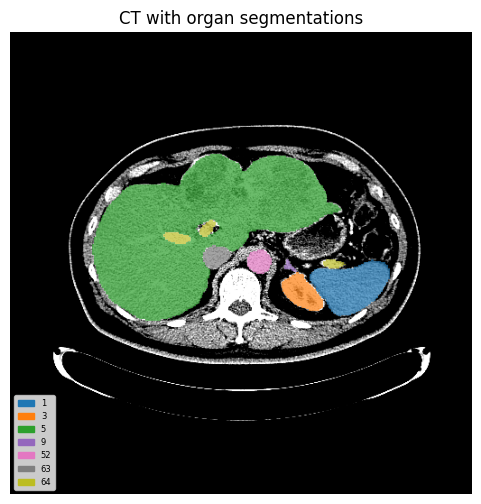

In [82]:
plt.figure(figsize=(6,6))
plt.imshow(window_ct(np.rot90(image_array[0, :, :, slice], k=1)), cmap="gray")

colors = plt.get_cmap("tab10", len(ORGANS))
legend_patches = []

organ_names = list(ORGANS.keys())

for i, organ_name in enumerate(organ_names):
    mask = organ_array[i, :, :, slice]

    if mask.sum() == 0:
        continue

    color = colors(i)
    rgba = np.zeros((*mask.shape, 4))
    rgba[..., :3] = color[:3]
    rgba[..., 3] = mask * 0.7  # transparency only where mask==1

    plt.imshow(np.rot90(rgba, k=1))

    legend_patches.append(
        Patch(color=color[:3], label=organ_name)
    )

plt.legend(
    handles=legend_patches,
    loc="lower left",
    framealpha=0.8,
    fontsize=6
)

plt.title("CT with organ segmentations")
plt.axis("off")
plt.show()

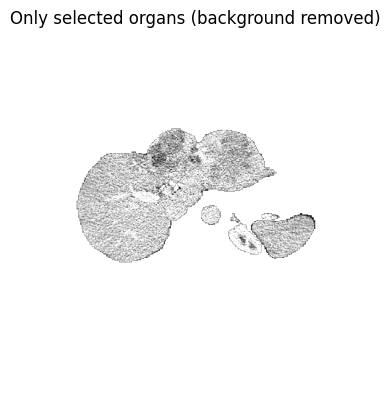

In [83]:
# Remove channel dims
ct = image_array.squeeze(0)       # [H, W, D]
organ_array_single.squeeze(0)     # [H, W, D]
combined_mask = (organ_array > 0).any(axis=0) # if voxel belongs to any organ (1st dimension = 0) => True, else False

# Apply mask

slice_ct = ct[:, :, slice]
slice_mask = combined_mask[:, :, slice]


masked_slice = np.where(
    (slice_mask > 0) & (slice_mask < 300), # Remove background and restrict to soft tissue 
    slice_ct,
    np.nan
)

# Plot
plt.imshow(np.rot90(window_ct(masked_slice), k=1), cmap="gray")
plt.title("Only selected organs (background removed)")
plt.axis("off")
plt.show()

In [66]:
print(image_array.shape, organ_array.shape)

torch.Size([1, 512, 512, 167]) (13, 512, 512, 167)


In [99]:
import torch.nn.functional as F

def keep_organ_volume(image_array, organ_array):
    mask = torch.tensor((organ_array > 0).any(axis=0), device=image_array.device)

    coords = mask.nonzero()

    h_min, w_min, d_min = coords.min(dim=0).values
    h_max, w_max, d_max = coords.max(dim=0).values

    ct_cropped = image_array.clone()

    ct_cropped = ct_cropped[
        :,
        h_min:h_max+1,
        w_min:w_max+1,
        d_min:d_max+1
    ]

    mask_cropped = mask[h_min:h_max+1, w_min:w_max+1, d_min:d_max+1]

    ct_cropped[:, ~mask_cropped] = -1024

    return ct_cropped

def pad_to_shape(x, target_shape):
    """
    Pads a 3D image (C, H, W, D) to target_shape, centering the image in the padded volume.
    Pads with -1024 (air in CT).
    """
    _, H, W, D = x.shape
    _, Ht, Wt, Dt = target_shape

    pad_H = Ht - H
    pad_W = Wt - W
    pad_D = Dt - D

    # compute padding before and after for each dimension
    pad_H_before = pad_H // 2
    pad_H_after = pad_H - pad_H_before

    pad_W_before = pad_W // 2
    pad_W_after = pad_W - pad_W_before

    pad_D_before = pad_D // 2
    pad_D_after = pad_D - pad_D_before

    # F.pad expects padding in reverse order: (D, W, H)
    pad = (pad_D_before, pad_D_after,
           pad_W_before, pad_W_after,
           pad_H_before, pad_H_after)

    return F.pad(x, pad, value=-1024)  # use -1024 pading value because air ~ -1024 HU

In [101]:
ct_cropped = keep_organ_volume(image_array, organ_array)
ct_cropped.shape

torch.Size([1, 334, 189, 134])

In [102]:
ct_padded = pad_to_shape(ct_cropped, [1,400, 400, 150])
ct_padded.shape

torch.Size([1, 400, 400, 150])

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

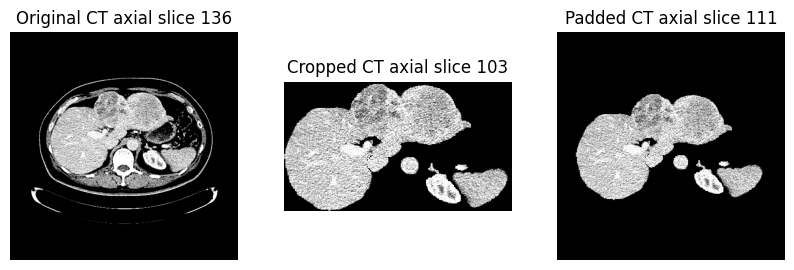

In [120]:
slice = 136
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(window_ct(np.rot90(image_array[0, :, :, slice], k=1)), cmap="gray")
plt.title(f"Original CT axial slice {slice}") 
plt.axis("off")

slice_cropped = slice-(image_array.shape[3]-ct_cropped.shape[3]) # slices are 'lost' in the cropping
plt.subplot(1,3,2)
plt.imshow(np.rot90(window_ct(ct_cropped[0][:, :, slice_cropped]), k=1), cmap="gray") # 30 slices are 'lost' in the cropping
plt.title(f"Cropped CT axial slice {slice_cropped}")
plt.axis("off")

slice_padded = slice_cropped+((slice-slice_cropped)//2 - (slice-slice_cropped)//4)  # half of the slices are added on each side after padding
plt.subplot(1,3,3)
plt.imshow(np.rot90(window_ct(ct_padded[0][:, :, slice_padded]), k=1), cmap="gray") 
plt.title(f"Padded CT axial slice {slice_padded}")
plt.axis("off")

In [72]:
from sklearn.preprocessing import LabelEncoder

class PTDataset(Dataset):
    def __init__(self, folder, encoder=None, sample=5):
        self.files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.endswith(".pt")
        ])

        if sample:
            self.files = self.files[:sample]

        # Load all labels once
        self.raw_labels = []
        for f in self.files:
            data = torch.load(f)
            self.raw_labels.append(data["contrast"])

        # Fit encoder once
        if encoder is None:
            self.le = LabelEncoder()
            self.le.fit(self.raw_labels)
        else:
            self.le = encoder

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx])

        image = data["image"]
        label = str(data["contrast"])
        label = self.le.transform([label])[0]
        label = torch.tensor(label, dtype=torch.long)

        return {
            "image": image,
            "label": label
        }

In [73]:
path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_preprocessed"
train_dataset = PTDataset(f"{path}/train", sample=20)
le = train_dataset.le
val_dataset = PTDataset(f"{path}/val", encoder=le, sample=20)
test_dataset = PTDataset(f"{path}/test", encoder=le, sample=20)

In [74]:
len(train_dataset), len(val_dataset), len(test_dataset)

(20, 20, 20)

In [75]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

for batch in train_loader:
    images = batch["image"]
    labels = batch["label"]
    print("Image shape:", images.shape, "Labels:", labels, flush=True)
    break

Image shape: torch.Size([2, 1, 128, 128, 128]) Labels: tensor([1, 1])


In [76]:
class Small3DCNN_1(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # First convolutional block
        self.conv1 = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        # Second convolutional block
        self.conv2 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        # AdaptiveAvgPool3d(1) adaptively collapses spatial dims
        self.adaptive_pool = nn.AdaptiveAvgPool3d(1)

        # Classifier
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the feature map
        x = self.adaptive_pool(x)  # shape: (batch, 32, 1, 1, 1)
        x = torch.flatten(x, 1)    # shape: (batch, 32)

        out = self.classifier(x)
        return out

In [ ]:

from monai.networks.nets import resnet10
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
 

def train_cnn(model, train_loader, weights=None, val_loader=None, epochs=10, lr=1e-4, weight_decay = 1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    if weights is not None:
        weights = weights.to(device)

    loss_fn = CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 3
    counter = 0
    best_model_state = None

    for epoch in range(epochs):


        # -------------------- TRAIN --------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for batch in loop:
            images = batch["image"].to(device)
            labels = batch["label"].long().to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()


            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)            # outputs = logits => pick the highest logit as the class label
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            loop.set_postfix(
                loss=loss.item(),
                acc=train_correct / train_total if train_total else 0.0
            )

        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total if train_total else 0.0


        # -------------------- VALIDATION --------------------
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for batch in val_loader:
                    images = batch["image"].to(device)
                    labels = batch["label"].long().to(device)


                    outputs = model(images)
                    loss = loss_fn(outputs, labels)

                    val_loss += loss.item()
                    preds = torch.argmax(outputs, dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            avg_val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_total if val_total else 0.0

            print(
                f"Epoch {epoch+1}: "
                f"train_loss={avg_train_loss:.4f}, train_acc={train_acc:.4f} | "
                f"val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}",
                flush=True
            )

            # Early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                counter = 0
                best_model_state = model.state_dict()  # saving best weights
                print("New best model")
            else:
                counter += 1
                print(f"No improvement ({counter}/{patience})")

                if counter >= patience:
                    print("Early stopping triggered")
                    break

    # Loading the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


In [77]:
model = Small3DCNN_1(num_classes=len(le.classes_))

trained_model = train_cnn(model,
                        train_loader,
                        weights = None,
                        val_loader=val_loader,
                        epochs = 5)

Epoch 1: train_loss=0.7114, train_acc=0.5500 | val_loss=0.6841, val_acc=0.6000
New best model


Epoch 2: train_loss=0.7195, train_acc=0.5500 | val_loss=0.6843, val_acc=0.6000
No improvement (1/3)


Epoch 3: train_loss=0.6955, train_acc=0.5500 | val_loss=0.6905, val_acc=0.6500
No improvement (2/3)


Epoch 4: train_loss=0.7021, train_acc=0.5500 | val_loss=0.6946, val_acc=0.4000
No improvement (3/3)
Early stopping triggered


In [70]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, test_loader, device=None, class_names=None):
    """
    Evaluate a 3D CNN on a dataset.

    Args:
        model: Trained PyTorch model
        data_loader: DataLoader yielding {"image": tensor, "label": int}
        device: "cuda" or "cpu". If None, automatically uses CUDA if available
        class_names: list of class names for reporting

    Returns:
        metrics: dict with accuracy, classification report, and confusion matrix
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": cm
    }

    print(f"\nTest Accuracy: {acc:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)

    return metrics

In [78]:
evaluate_model(trained_model, test_loader, class_names=le.classes_)


Test Accuracy: 0.4500
Classification Report:
               precision    recall  f1-score   support

    Arterial       0.00      0.00      0.00        11
      Portal       0.45      1.00      0.62         9

    accuracy                           0.45        20
   macro avg       0.23      0.50      0.31        20
weighted avg       0.20      0.45      0.28        20

Confusion Matrix:
 [[ 0 11]
 [ 0  9]]


{'accuracy': 0.45,
 'classification_report': '              precision    recall  f1-score   support\n\n    Arterial       0.00      0.00      0.00        11\n      Portal       0.45      1.00      0.62         9\n\n    accuracy                           0.45        20\n   macro avg       0.23      0.50      0.31        20\nweighted avg       0.20      0.45      0.28        20\n',
 'confusion_matrix': array([[ 0, 11],
        [ 0,  9]])}

# Time Interval Estimation

In [68]:
contrast_data = data[data.contrast.isin(["Arterial", "Portal"])]

# Include only exams with both arterial and portal
required_phases = {"Arterial", "Portal"}

pairs = (
    contrast_data
    .groupby(["SubjectKeyRadiology", "ExamDate"])
    .filter(lambda g: required_phases.issubset(set(g["contrast"])))
    .sort_values(by=["SubjectKeyRadiology", "ExamDate", "contrast"])
)

In [69]:
pairs[["SubjectKeyRadiology", "ExamDate", "contrast", "phase_timing", "AcquisitionTime"]]

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime
108,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320
213,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510
176,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early,11:18:35.166000
813,NKI-d23231-00-0005,2010-02-04,Portal,Just Right,11:19:28.813790
785,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early,14:08:8.950000
...,...,...,...,...,...
8729,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,15:13:16.119320
8730,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,12:05:45.561000
8731,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,12:06:20.138000
8732,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,11:43:20.650000


In [70]:
pairs["AcquisitionTime_sec"] = pd.to_timedelta(pairs["AcquisitionTime"]).dt.total_seconds()
pairs = pairs[["MatchKey", "SubjectKeyRadiology", "ExamDate", "contrast", "phase_timing", "AcquisitionTime", "AcquisitionTime_sec"]]
pairs

,MatchKey,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,AcquisitionTime_sec
108,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320,43430.15132
213,NKI-d23231-00-0002_20151201_kalina04_0039.nii.gz,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510,43430.15651
176,NKI-d23231-00-0005_20100204_kalina04_0000.nii.gz,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early,11:18:35.166000,40715.16600
813,NKI-d23231-00-0005_20100204_kalina99_0007.nii.gz,NKI-d23231-00-0005,2010-02-04,Portal,Just Right,11:19:28.813790,40768.81379
785,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early,14:08:8.950000,50888.95000
...,...,...,...,...,...,...,...
8729,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,15:13:16.119320,54796.11932
8730,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,12:05:45.561000,43545.56100
8731,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,12:06:20.138000,43580.13800
8732,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,11:43:20.650000,42200.65000


In [35]:
# pairs["time_interval"] = (
#     pairs
#     .groupby(["SubjectKeyRadiology", "ExamDate"])["AcquisitionTime_sec"]
#     .diff()
#     .shift(-1)
#     .ffill(limit = 1)
# )


# pairs[["MatchKey", "SubjectKeyRadiology", "ExamDate", "contrast", "phase_timing", "AcquisitionTime", "AcquisitionTime_sec", "time_interval"]]

,MatchKey,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,AcquisitionTime_sec,time_interval
108,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320,43430.15132,0.00519
213,NKI-d23231-00-0002_20151201_kalina04_0039.nii.gz,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510,43430.15651,0.00519
176,NKI-d23231-00-0005_20100204_kalina04_0000.nii.gz,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early,11:18:35.166000,40715.16600,53.64779
813,NKI-d23231-00-0005_20100204_kalina99_0007.nii.gz,NKI-d23231-00-0005,2010-02-04,Portal,Just Right,11:19:28.813790,40768.81379,53.64779
785,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early,14:08:8.950000,50888.95000,33.40000
...,...,...,...,...,...,...,...,...
8729,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,15:13:16.119320,54796.11932,31.78189
8730,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,12:05:45.561000,43545.56100,34.57700
8731,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,12:06:20.138000,43580.13800,34.57700
8732,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,11:43:20.650000,42200.65000,29.39200


In [71]:
pairs_wide = pairs.pivot_table(
    index=["SubjectKeyRadiology", "ExamDate"],
    columns="contrast",
    values="AcquisitionTime_sec",
    aggfunc="first"   # handles duplicates safely
).reset_index()

pairs_wide

contrast,SubjectKeyRadiology,ExamDate,Arterial,Portal
0,NKI-d23231-00-0002,2015-12-01,43430.15132,43430.15651
1,NKI-d23231-00-0005,2010-02-04,40715.16600,40768.81379
2,NKI-d23231-00-0005,2012-06-18,50888.95000,50922.35000
3,NKI-d23231-00-0005,2022-05-11,50322.27760,50353.12040
4,NKI-d23231-00-0005,2022-10-17,51524.37000,51557.12200
...,...,...,...,...
1784,NKI-d23231-00-0887,2023-05-24,49255.70500,49287.28300
1785,NKI-d23231-00-0887,2023-08-30,47716.70000,47745.60000
1786,NKI-d23231-00-0888,2022-04-20,54764.33743,54796.11932
1787,NKI-d23231-00-0888,2023-04-24,43545.56100,43580.13800


In [72]:
pairs_wide["time_interval"] = pairs_wide.Portal - pairs_wide.Arterial
pairs_wide


contrast,SubjectKeyRadiology,ExamDate,Arterial,Portal,time_interval
0,NKI-d23231-00-0002,2015-12-01,43430.15132,43430.15651,0.00519
1,NKI-d23231-00-0005,2010-02-04,40715.16600,40768.81379,53.64779
2,NKI-d23231-00-0005,2012-06-18,50888.95000,50922.35000,33.40000
3,NKI-d23231-00-0005,2022-05-11,50322.27760,50353.12040,30.84280
4,NKI-d23231-00-0005,2022-10-17,51524.37000,51557.12200,32.75200
...,...,...,...,...,...
1784,NKI-d23231-00-0887,2023-05-24,49255.70500,49287.28300,31.57800
1785,NKI-d23231-00-0887,2023-08-30,47716.70000,47745.60000,28.90000
1786,NKI-d23231-00-0888,2022-04-20,54764.33743,54796.11932,31.78189
1787,NKI-d23231-00-0888,2023-04-24,43545.56100,43580.13800,34.57700


In [73]:
pairs_wide.sort_values(by="time_interval")

contrast,SubjectKeyRadiology,ExamDate,Arterial,Portal,time_interval
1052,NKI-d23231-00-0348,2013-11-12,51090.55000,51072.40000,-18.15000
0,NKI-d23231-00-0002,2015-12-01,43430.15132,43430.15651,0.00519
1115,NKI-d23231-00-0382,2015-08-28,48383.84953,48400.10851,16.25898
1089,NKI-d23231-00-0360,2015-12-21,56663.85000,56680.85000,17.00000
692,NKI-d23231-00-0222,2015-01-05,59810.55000,59827.95000,17.40000
...,...,...,...,...,...
431,NKI-d23231-00-0146,2006-09-20,43161.31552,43286.52369,125.20817
72,NKI-d23231-00-0043,2007-05-01,53429.00000,53555.00000,126.00000
1506,NKI-d23231-00-0621,2008-09-04,57739.00000,57897.00000,158.00000
363,NKI-d23231-00-0109,2006-12-14,54751.07776,55039.59352,288.51576


In [74]:
pairs = pairs.merge(pairs_wide[["SubjectKeyRadiology","ExamDate", "time_interval"]], how = "left", on = ["SubjectKeyRadiology","ExamDate"]).sort_values(by="time_interval").reset_index(drop=True)

In [75]:
pairs

,MatchKey,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,AcquisitionTime_sec,time_interval
0,NKI-d23231-00-0348_20131112_kalina99_1904.nii.gz,NKI-d23231-00-0348,2013-11-12,Arterial,Just Right,14:11:30.550000,51090.55000,-18.15000
1,NKI-d23231-00-0348_20131112_kalina01_0124.nii.gz,NKI-d23231-00-0348,2013-11-12,Portal,Just Right,14:11:12.400000,51072.40000,-18.15000
2,NKI-d23231-00-0002_20151201_kalina04_0039.nii.gz,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510,43430.15651,0.00519
3,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320,43430.15132,0.00519
4,NKI-d23231-00-0382_20150828_kalina01_0152.nii.gz,NKI-d23231-00-0382,2015-08-28,Arterial,Just Right,13:26:23.849530,48383.84953,16.25898
...,...,...,...,...,...,...,...,...
3745,NKI-d23231-00-0109_20061214_david01_0143.nii.gz,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,15:17:19.593520,55039.59352,288.51576
3746,NKI-d23231-00-0109_20061214_kalina99_0057.nii.gz,NKI-d23231-00-0109,2006-12-14,Arterial,Just Right,15:12:31.077760,54751.07776,288.51576
3747,NKI-d23231-00-0109_20061214_kalina99_0056.nii.gz,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,15:10:56.432010,54656.43201,288.51576
3748,NKI-d23231-00-0762_20191227_kalina99_5028.nii.gz,NKI-d23231-00-0762,2019-12-27,Arterial,Just Right,08:34:59.409000,30899.40900,471.47600


In [76]:
pairs.info()

<class 'pandas.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MatchKey             3750 non-null   str    
 1   SubjectKeyRadiology  3750 non-null   str    
 2   ExamDate             3750 non-null   str    
 3   contrast             3750 non-null   str    
 4   phase_timing         3750 non-null   str    
 5   AcquisitionTime      3750 non-null   str    
 6   AcquisitionTime_sec  3750 non-null   float64
 7   time_interval        3750 non-null   float64
dtypes: float64(2), str(6)
memory usage: 631.5 KB


In [95]:
import os
import pandas as pd
from pathlib import PureWindowsPath


def create_paired_data(dataset):
    dataset = dataset.copy()

    # Assign server folder
    dataset["server_folder"] = dataset["exist_on_server"].apply(
        lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"
        if pd.notna(x)
        else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server"
    )

    # Filter valid rows
    dataset = dataset[
        (dataset.contrast.isin(["Arterial", "Portal"])) &
        (dataset.is_liver_imaged == "Yes") &
        (dataset.phase_timing != "0.0")
    ].copy()

    # Convert time once
    dataset["AcquisitionTime_sec"] = pd.to_timedelta(
        dataset["AcquisitionTime"]
    ).dt.total_seconds()

    # Keep only exams with both phases
    required_phases = {"Arterial", "Portal"}

    paired_data = (
        dataset
        .sort_values(["SubjectKeyRadiology", "ExamDate", "AcquisitionTime_sec"])
        .groupby(["SubjectKeyRadiology", "ExamDate", "server_folder"])
        .filter(lambda g: required_phases.issubset(set(g["contrast"])))
    )

    return paired_data

def build_pairs(dataset):

    paired_data = create_paired_data(dataset)

    pairs = []

    # Per exam
    for (patient_id, exam_date, server_folder), group in paired_data.groupby(
        ["SubjectKeyRadiology", "ExamDate", "server_folder"]
    ):

        group = group.sort_values("AcquisitionTime_sec")

        arterial = group[group["contrast"] == "Arterial"]
        portal = group[group["contrast"] == "Portal"]

        if arterial.empty or portal.empty:
            continue

        # For each arterial, pair with ALL future portal variants
        for _, a_row in arterial.iterrows():

            a_time = a_row["AcquisitionTime_sec"]

            future_portals = portal[portal["AcquisitionTime_sec"] > a_time]

            if future_portals.empty:
                continue

            a_file = os.path.join(
                server_folder,
                PureWindowsPath(a_row["MatchKey"]).name
            )

            # Preserve multiple kernel reconstructions
            for _, p_row in future_portals.iterrows():

                p_time = p_row["AcquisitionTime_sec"]
                interval = p_time - a_time

                if interval <= 0:
                    continue

                p_file = os.path.join(
                    server_folder,
                    PureWindowsPath(p_row["MatchKey"]).name
                )

                pairs.append({
                    "SubjectKeyRadiology": patient_id,
                    "ExamDate": exam_date,

                    "arterial_file": a_file,
                    "portal_file": p_file,

                    "arterial_organs": a_file.replace(".nii.gz", ".organs.nii.gz"),
                    "portal_organs": p_file.replace(".nii.gz", ".organs.nii.gz"),

                    # SAME arterial anchor
                    "time_interval": interval
                })

    return pd.DataFrame(pairs).reset_index(drop=True)

In [96]:
def files_load(data_dir, sample=None):

    dataset = pd.read_csv(data_dir)

    paired_data = create_paired_data(dataset)
    
    # -------- build pairs --------
    pairs_df = build_pairs(paired_data)

    # -------- optional sampling --------
    if sample:
        pairs_df = pairs_df.sample(n=sample, random_state=42)

    return (
        pairs_df["SubjectKeyRadiology"].tolist(),
        pairs_df["ExamDate"].tolist(),

        pairs_df["arterial_file"].tolist(),
        pairs_df["portal_file"].tolist(),
        pairs_df["arterial_organs"].tolist(),
        pairs_df["portal_organs"].tolist(),
        pairs_df["time_interval"].tolist()
    )

In [93]:
pairs = build_pairs(data)
pairs

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,portal_organs,time_interval
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0.00519
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,53.64779
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,33.40000
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,30.84280
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,32.75200
...,...,...,...,...,...,...,...
1537,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,31.57800
1538,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,28.90000
1539,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,31.78189
1540,NKI-d23231-00-0888,2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,34.57700


In [ ]:
data_dir = "/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv"
patient_ids, dates, a_files, p_files, a_organs, p_organs, intervals = files_load(data_dir, sample=None)  